In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

class Paths:
    p = "/Users/shirokoshikentaro/Desktop/Python3/house-prices-advanced-regression-techniques"
    train = p + "/train.csv"
    test = p + "/test.csv"
    sample = p + "/sample_submission.csv"

# ===== ステップ1: データ読み込み =====
train = pd.read_csv(Paths.train)
test = pd.read_csv(Paths.test)

print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")

# ===== ステップ1.5: 外れ値除去（最重要！）=====
print("外れ値除去前:", len(train))
# GrLivAreaが異常に大きいのに価格が低い物件を除去
train = train.drop(train[(train['GrLivArea']>4000) & (train['SalePrice']<300000)].index)
# LotAreaが異常に大きい物件を除去
train = train[train['LotArea'] < 100000]
print("外れ値除去後:", len(train))

# ===== ステップ2: 目的変数を先に取り出す =====
y_train = np.log1p(train["SalePrice"].values)  # .values で numpy配列に
print(f"y_train shape: {y_train.shape}")  # (1460,) であるべき

# ===== ステップ3: 新規特徴量作成 =====
for df in [train, test]:
    df["QualGrLiv"] = df["OverallQual"] * df["GrLivArea"]
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["QualTotalSF"] = df["OverallQual"] * df["TotalSF"]
    df["Age"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["TotalBath"] = (df["FullBath"] + 0.5*df["HalfBath"].fillna(0) + 
                       df["BsmtFullBath"].fillna(0) + 0.5*df["BsmtHalfBath"].fillna(0))
    df["AreaPerRoom"] = df["GrLivArea"] / df["TotRmsAbvGrd"].replace(0, 1)
    df["GarageScore"] = df["GarageCars"] * df["GarageArea"]

    # log変換した特徴量を追加
    df["Log_GrLivArea"] = np.log1p(df["GrLivArea"])
    df["Log_LotArea"] = np.log1p(df["LotArea"])
    df["Log_TotalSF"] = np.log1p(df["TotalSF"])

    # フラグ特徴量
    df["HasPool"] = (df["PoolArea"] > 0).astype(int)
    df["Has2ndFloor"] = (df["2ndFlrSF"] > 0).astype(int)
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["HasBsmt"] = (df["TotalBsmtSF"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    
    # 品質関連特徴量
    df["TotalQual"] = df["OverallQual"] + df["OverallCond"]
    df["QualBath"] = df["OverallQual"] * df["TotalBath"]
    df["QualCond"] = df["OverallQual"] * df["OverallCond"]


# ===== ステップ4: 特徴量定義 =====
num_features = [
    "LotArea", "YearBuilt", "YearRemodAdd",
    "GrLivArea", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
    "FullBath", "BedroomAbvGr", "TotRmsAbvGrd",
    "GarageCars", "GarageArea", "OverallQual", "OverallCond",
    "QualGrLiv", "TotalSF", "QualTotalSF", 
    "Age", "RemodAge", "TotalBath", "AreaPerRoom", "GarageScore",
    "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
    "Fireplaces", "HalfBath", "BsmtFullBath",

    # ⭐ここに新しい特徴量を追加！
    "HasPool", "Has2ndFloor", "HasGarage", "HasBsmt", "HasFireplace",
    "TotalQual", "QualBath", "QualCond","Log_GrLivArea", "Log_LotArea", "Log_TotalSF",
]

cat_features = [
    "Neighborhood", "BldgType", "HouseStyle",
    "MSZoning", "Foundation", "GarageType",
    "ExterQual", "KitchenQual", "BsmtQual",
    "HeatingQC", "FireplaceQu", "GarageFinish",
]

all_features = num_features + cat_features
print(f"総特徴量: {len(all_features)}個")

# ===== ステップ5: 欠損値処理 =====
print("欠損値処理中...")
# 数値特徴量:0で埋める
for col in num_features:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# カテゴリ特徴量:"None"で埋める
for col in cat_features:
    train[col] = train[col].fillna("None")
    test[col] = test[col].fillna("None")

# # 数値特徴量：中央値で埋める（trainの中央値を使用）
# for col in num_features:
#     if train[col].isnull().sum() > 0:
#         # trainの中央値を計算
#         median_value = train[col].median()
#         print(f"  {col}: 欠損{train[col].isnull().sum()}個 → 中央値{median_value:.1f}で埋める")
        
#         # trainとtestを埋める
#         train[col] = train[col].fillna(median_value)
#         test[col] = test[col].fillna(median_value)

# # カテゴリ特徴量：最頻値で埋める（trainの最頻値を使用）
# for col in cat_features:
#     if train[col].isnull().sum() > 0:
#         # trainの最頻値を計算
#         mode_value = train[col].mode()[0]  # mode()は配列を返すので[0]で最初の値
#         print(f"  {col}: 欠損{train[col].isnull().sum()}個 → 最頻値'{mode_value}'で埋める")
        
#         # trainとtestを埋める
#         train[col] = train[col].fillna(mode_value)
#         test[col] = test[col].fillna(mode_value)

# ===== ステップ6: エンコーディング =====
for col in cat_features:
    le = LabelEncoder()
    combined = pd.concat([train[col].astype(str), test[col].astype(str)])
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

# ===== ステップ7: X_train, X_test作成 =====
X_train = train[all_features].values  # numpy配列に
X_test = test[all_features].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")

# ===== ステップ8: CV =====
params = {
    "boosting_type": "gbdt",
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 16,
    "learning_rate": 0.1,
    "n_estimators": 10000,
    "random_state": 123,
    "verbose": -1,
}

cv = KFold(n_splits=5, shuffle=True, random_state=123)
metrics = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
    
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    metrics.append(rmse)
    print(f"Fold {fold}: {rmse:.5f}")

print(f"\n[CV] {np.mean(metrics):.5f}±{np.std(metrics):.5f}")

# ===== ステップ9: 全データで学習 & 予測 =====
model = lgb.LGBMRegressor(**params)

model.fit(X_train, y_train, 
          eval_set=[(X_train, y_train)],
          callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)])

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

# ===== ステップ10: 提出ファイル =====
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_pred
})

submission.to_csv("submission_fixed.csv", index=False)
print(f"\n✅ 保存完了！平均予測価格: ${y_pred.mean():,.0f}")

train shape: (1460, 81)
test shape: (1459, 80)
外れ値除去前: 1460
外れ値除去後: 1454
y_train shape: (1454,)
総特徴量: 51個
欠損値処理中...
X_train shape: (1454, 51)
X_test shape: (1459, 51)
y_train shape: (1454,)
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[74]	valid_0's rmse: 0.119588
Fold 0: 0.11959
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[84]	valid_0's rmse: 0.149927
Fold 1: 0.14993
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[127]	valid_0's rmse: 0.123059
Fold 2: 0.12306
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[81]	valid_0's rmse: 0.114286
Fold 3: 0.11429
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[118]	valid_0's rmse: 0.128297
Fold 4: 0.12830

[CV] 0.12703±0.01232
[100]	training's rmse: 0.0681569
[200]	training's rmse: 0.0473505
[300]

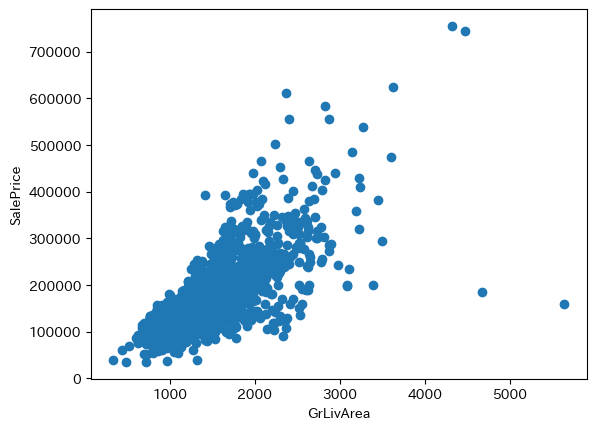

In [7]:
plt.scatter(train['GrLivArea'], train['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()